## Comparison of binomial tree and 1D neural network

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from neural_network.trainer import GeneralTrainer
from neural_network.payoff import Put
from neural_network.config import MarketParams, ModelConfig

from black_scholes.tree import BinomialTree

from utility.plot import plot_price_heatmaps, plot_free_boundary
from utility.continuation_prob import compute_continuation_probs

/Users/jameswu/Documents/Imperial/Year 4/M4R/M4R_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
S0 = 1.0
r = 0
sigma = 0.3
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)
exercise_type = "american"

In [3]:
bt = BinomialTree(market_params, exercise_type=exercise_type, n_steps=100)

In [4]:
input_size = 2
hidden_sizes = [64, 128, 128, 128, 64]
output_size = 1
activation = nn.Mish()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [5]:
put_payoff = Put()
trainer = GeneralTrainer(model_config, market_params, put_payoff, exercise_type=exercise_type, seed=42)

# optimal_weights = trainer.optimise_loss_weights(
#     batch_size=1000, n_trials=30, epochs_per_trial=300
# )

# optimal_weights = {
#     'pde': 0.19348338625682435,
#     'exercise': 0.3490385992215528,
#     'boundary_Smax': 0.01892782884360992,
#     'boundary_Smin': 0.43855018567801296
# }

optimal_weights = {
    'pde': 1,
    'exercise': 4,
    'boundary_Smax': 1,
    'boundary_Smin': 1
}

# print("Optimal Loss Weights:", optimal_weights)

In [6]:
trainer.set_loss_weights(optimal_weights)
print("Training with optimal loss weights...")
print(trainer.loss_weights)
trainer.train(batch_size=1000, epochs=10000, tol=1e-7)

Training with optimal loss weights...
{'pde': 0.14285714285714285, 'exercise': 0.5714285714285714, 'boundary_Smax': 0.14285714285714285, 'boundary_Smin': 0.14285714285714285}
Iteration 0	Training Loss: 0.3348426818847656	Validation Loss: 0.31118977069854736
Iteration 100	Training Loss: 0.0020180882420390844	Validation Loss: 0.0021016711834818125
Iteration 200	Training Loss: 0.0014441286912187934	Validation Loss: 0.0014445430133491755
Iteration 300	Training Loss: 0.0009027004125528038	Validation Loss: 0.0008762360084801912
Iteration 400	Training Loss: 0.000524559523910284	Validation Loss: 0.0005232715047895908
Iteration 500	Training Loss: 0.00017979547556024045	Validation Loss: 0.00016270285414066166
Iteration 600	Training Loss: 0.00010577850480331108	Validation Loss: 0.00011744533549062908
Iteration 700	Training Loss: 7.604676648043096e-05	Validation Loss: 8.519103721482679e-05
Iteration 800	Training Loss: 6.735695205861703e-05	Validation Loss: 6.730588938808069e-05
Iteration 900	Train

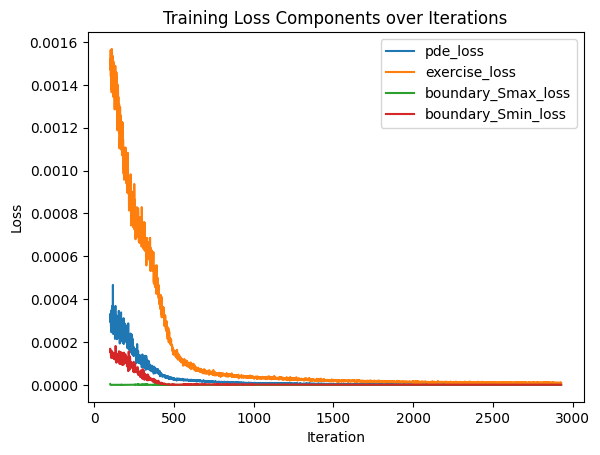

In [7]:
trainer.plot_losses_detailed(start_epoch=100)

In [8]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))
intrinsics = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = trainer.predict(t_val, s_val).item()
        bt_prices[i, j] = bt.predict(t_val, s_val)

/var/folders/yc/lmxhkkxd611c8bx7dqjsmvr40000gn/T/ipykernel_8195/664654973.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bt_prices[i, j] = bt.predict(t_val, s_val)


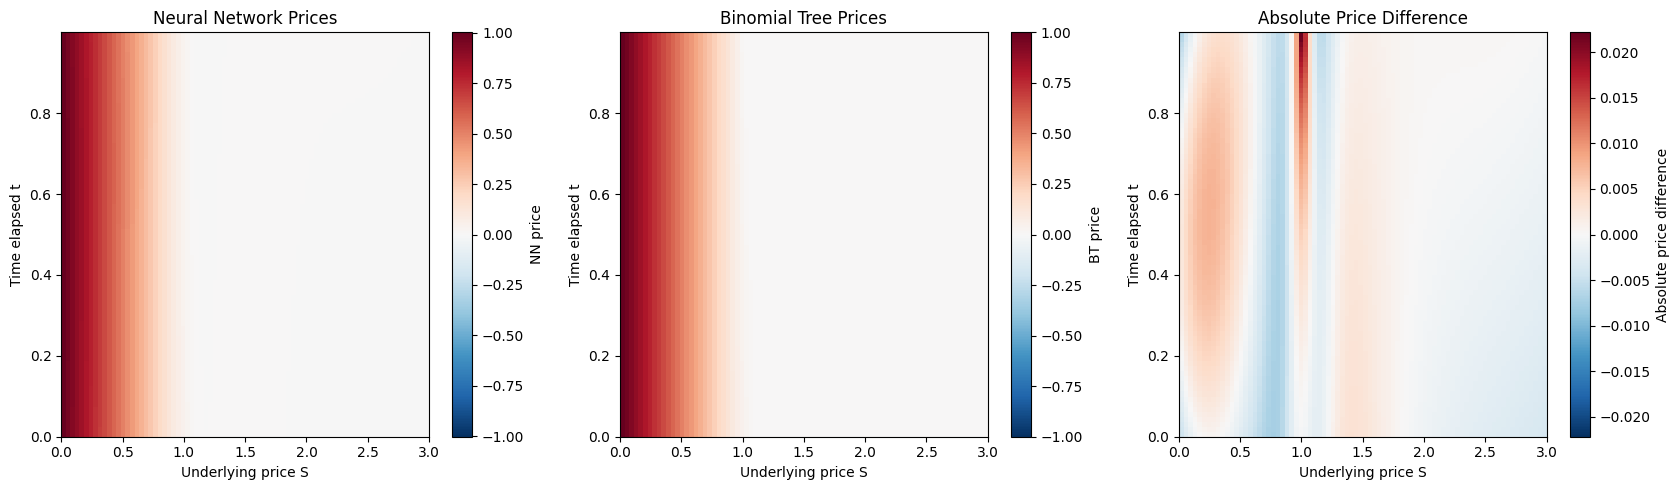

In [9]:
plot_price_heatmaps(
    prices1=nn_prices, prices2=bt_prices,
    xlabel='Underlying price S', ylabel='Time elapsed t',
    title1='Neural Network Prices', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
    label1='NN price', label2='BT price', label_diff='Absolute price difference',
    extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]]
)

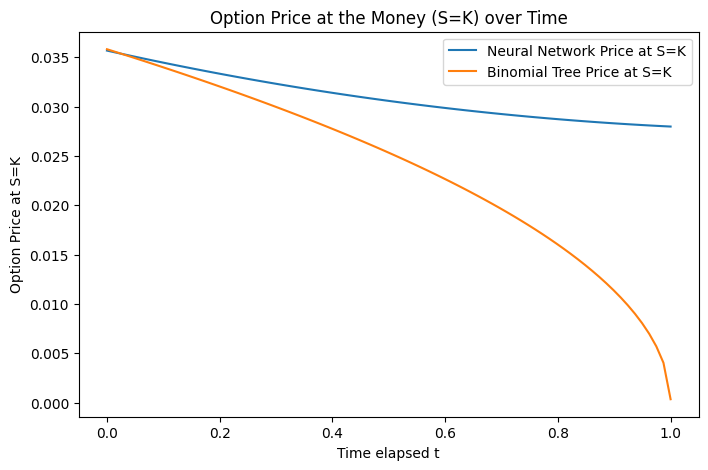

In [10]:
# Error at the money
S_try = K
nn_prices_atm = [trainer.predict(t, S_try).item() for t in Ts]
bt_prices_atm = [bt.predict(t, S_try) for t in Ts]

plt.figure(figsize=(8, 5))
plt.plot(Ts, nn_prices_atm, label='Neural Network Price at S=K')
plt.plot(Ts, bt_prices_atm, label='Binomial Tree Price at S=K')
plt.xlabel('Time elapsed t')
plt.ylabel('Option Price at S=K')
plt.title('Option Price at the Money (S=K) over Time')
plt.legend()
plt.show()

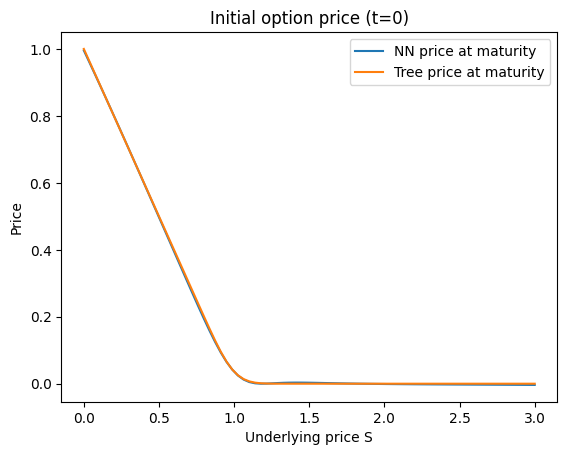

In [11]:
# Initial price
t_ind = 0
plt.plot(Ss, nn_prices[t_ind, :], label='NN price at maturity')
plt.plot(Ss, bt_prices[t_ind, :], label='Tree price at maturity')
# plt.plot(Ss, put_payoff.smoothed(torch.tensor(Ss), K, beta=50), label='Smoothed Payoff at maturity')
plt.xlabel('Underlying price S')
plt.ylabel('Price')
plt.title('Initial option price (t=0)')
plt.legend()
plt.show()

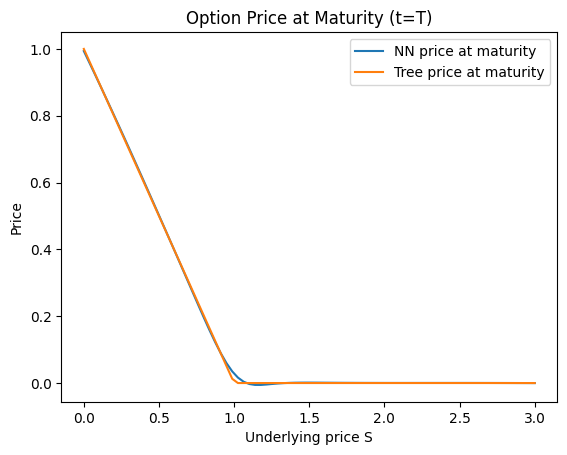

In [12]:
# Payoff price
t_ind = -1
plt.plot(Ss, nn_prices[t_ind, :], label='NN price at maturity')
plt.plot(Ss, bt_prices[t_ind, :], label='Tree price at maturity')
# plt.plot(Ss, put_payoff.smoothed(torch.tensor(Ss), K, beta=50), label='Smoothed Payoff at maturity')
plt.xlabel('Underlying price S')
plt.ylabel('Price')
plt.title('Option Price at Maturity (t=T)')
plt.legend()
plt.show()

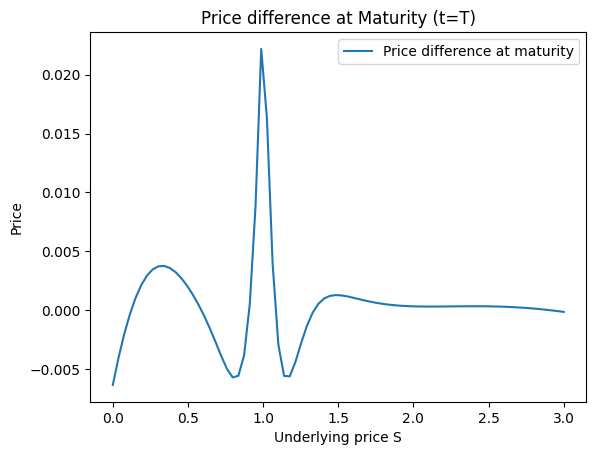

In [13]:
# Payoff price
t_ind = -1
plt.plot(Ss, nn_prices[t_ind, :] - bt_prices[t_ind, :], label='Price difference at maturity')
plt.xlabel('Underlying price S')
plt.ylabel('Price')
plt.title('Price difference at Maturity (t=T)')
plt.legend()
plt.show()

### Fine tune the network

In [14]:
# trainer.fine_tune(batch_size=1000, epochs=10000, tol=1e-2)

In [15]:
# # grid resolution
# num_S = 80
# num_T = 80

# Ss = np.linspace(S_min, S_max, num_S)
# Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

# nn_prices = np.zeros((num_T, num_S))
# bt_prices = np.zeros((num_T, num_S))

# for i, t_val in enumerate(Ts):
#     for j, s_val in enumerate(Ss):
#         nn_prices[i, j] = trainer.predict(t_val, s_val).item()
#         bt_prices[i, j] = bt.predict(t_val, s_val)

In [16]:
# plot_price_heatmaps(
#     prices1=nn_prices, prices2=bt_prices,
#     xlabel='Underlying price S', ylabel='Time elapsed t',
#     title1='Neural Network Prices (finetuned)', title2='Binomial Tree Prices', title_diff='Absolute Price Difference',
#     label1='NN price', label2='BT price', label_diff='Absolute price difference',
#     extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]]
# )

## Free boundary

In [17]:
# grid resolution
num_S = 200
num_T = 200

Ss = np.linspace(0.7, 1.1, num_S)
Ts = np.linspace(0, T-1e-4, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))
intrinsics = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = trainer.predict(t_val, s_val).item()
        bt_prices[i, j] = bt.predict(t_val, s_val)
        intrinsics[i, j] = max(0, K - s_val)

/var/folders/yc/lmxhkkxd611c8bx7dqjsmvr40000gn/T/ipykernel_8195/3733979399.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bt_prices[i, j] = bt.predict(t_val, s_val)


In [18]:
cont_probs_bt = compute_continuation_probs(bt_prices, intrinsics, eps1=1e-4, eps2=1e-1, one=0.99, shift=-1e-4)
cont_probs_nn = compute_continuation_probs(nn_prices, intrinsics, eps1=1e-2, eps2=2, one=0.99, shift=0)

/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:34: RuntimeWarning: divide by zero encountered in divide
  d = (prices - intrinsics + shift) / intrinsics
/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:6: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


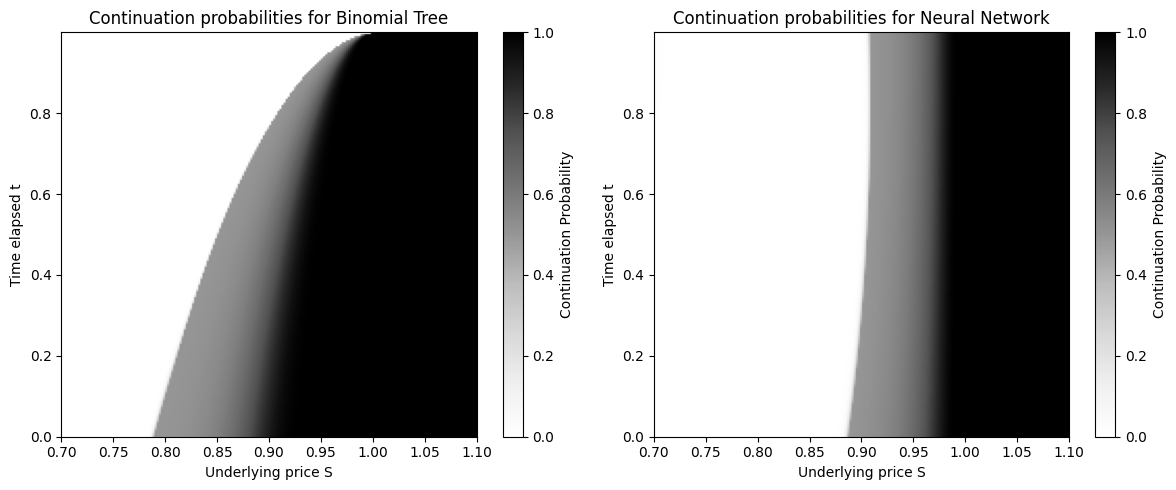

In [19]:
vmax = 1
vmin = 0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
im = plt.imshow(cont_probs_bt, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]], aspect='auto', origin='lower', cmap='Grays', vmin=vmin, vmax=vmax)
plt.colorbar(im, label="Continuation Probability")
plt.xlabel("Underlying price S")
plt.ylabel("Time elapsed t")
plt.title("Continuation probabilities for Binomial Tree")


plt.subplot(1, 2, 2)
im = plt.imshow(cont_probs_nn, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]], aspect='auto', origin='lower', cmap='Grays', vmin=vmin, vmax=vmax)
plt.colorbar(im, label="Continuation Probability")
plt.xlabel("Underlying price S")
plt.ylabel("Time elapsed t")
plt.title("Continuation probabilities for Neural Network")

plt.tight_layout()
plt.show()